# 03.2 — Feature Engineering (Sections 6.4–6.9)

Continues from `03.1`'s checkpoint (`comments_df` with the 6.1–6.3 features, plus the running `untrusted_features` list) and computes the rest of section 6: 6.4–6.9 (moved here to keep `03.1` to a manageable size). Hands off to `03.3` for the OP-relation features and the final combine step.

> Loads `results/03_1_comments_df.csv` and `results/03_1_untrusted_features.json` (output of `03.1`).

In [ ]:
import pandas as pd, json

comments_df = pd.read_csv('../results/03_1_comments_df.csv')
with open('../results/03_1_untrusted_features.json') as f:
    untrusted_features = json.load(f)

print(comments_df.shape)
print(untrusted_features)

(3971, 16)
['sentiment_vader', 'tone_label', 'style_label', 'ethos_score', 'pathos_score', 'logos_score']


In [ ]:
import common_functions

## 6.4 Rhetorical means
**Rhetorical means** refer to the strategies and techniques used to persuade or influence an audience in communication. They are central to the art of rhetoric and can be categorized into three main types: **ethos**, **pathos**, and **logos**. Together, these rhetorical means form the foundation of persuasive communication.

**Ethos** appeals to the speaker's credibility and character, aiming to establish trust with the audience.

**Pathos** focuses on evoking emotions, such as sympathy or anger, to connect with the audience on a personal level.

**Logos**, on the other hand, relies on logic and reasoning, using facts, statistics, and logical arguments to persuade the audience.

We would like to create feature with the amount of each rhetorical mean in each text.

Empath is an open-source text analysis library that categorizes words into psychologically meaningful themes, allowing users to extract insights about emotions, topics, and rhetorical strategies from text. We will use this library to calculate scores for each rhethorical mean in our data set.

In [ ]:
!pip install empath

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for empath: filename=empath-0.89-py3-none-any.whl size=57840 sha256=9c5351723712050397f6b1f93f30cebbbd0bde6b41da1895043f494bb1ab2e7f
  Stored in directory: /Users/dikla/Library/Caches/pip/wheels/b5/93/85/f4e8694df404eb214060dd0e0f3fda14398638f5835b3dde23
Successfully built empath

[notice] A new release of pip is available: 24.3.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip


In [ ]:
pathos_categories = ['hate', 'cheerfulness', 'aggression', 'envy', 'anticipation', 'fear', 'nervousness', 'horror', 'suffering', 'pride', 'sadness', 'optimism', 'irritability', 'surprise', 'exasperation', 'zest', 'confusion', 'love', 'sympathy', 'rage', 'emotional', 'joy', 'affection', 'shame', 'torment', 'anger', 'disappointment', 'pain', 'timidity', 'negative_emotion', 'positive_emotion', 'contentment']
ethos_categories = ['office', 'occupation', 'government', 'royalty', 'wealthy', 'journalism', 'banking', 'leader', 'independence', 'dominant_heirarchical', 'military', 'dominant_personality', 'science', 'work', 'philosophy', 'law', 'achievement']
logos_categories = ['money', 'medical_emergency', 'crime', 'dispute', 'government', 'school', 'computer', 'college', 'business', 'driving', 'internet', 'programming', 'economics', 'politics', 'technology', 'negotiate', 'payment']

In [ ]:
comments_df['ethos_score'] = None
comments_df['pathos_score'] = None
comments_df['logos_score'] = None

In [ ]:
from empath import Empath
import pandas as pd

lexicon = Empath()

def compute_rhetorical_scores():
  for index, row in comments_df.iterrows():
    if pd.isna(row['ethos_score']) or pd.isna(row['pathos_score']) or pd.isna(row['logos_score']):  # calculate only if wasn't calculated yet
      print(f"Calculating rhethorical means for index {index}")
      if isinstance(row['thread_text'], str):
        text = row['thread_text'] + "\n" + row['final_comment']
      else:
        text = row['final_comment']

      analysis = lexicon.analyze(text, normalize=True)  # Normalize to percentage

      ethos_score = sum(analysis[cat] for cat in ethos_categories)
      pathos_score = sum(analysis[cat] for cat in pathos_categories)
      logos_score = sum(analysis[cat] for cat in logos_categories)

      comments_df.at[index, 'ethos_score'] = ethos_score
      comments_df.at[index, 'pathos_score'] = pathos_score
      comments_df.at[index, 'logos_score'] = logos_score

In [ ]:
import os

rhetorical_checkpoint = '../results/comments_df_rhetorical_checkpoint.csv'
if os.path.exists(rhetorical_checkpoint):
  comments_df = pd.read_csv(rhetorical_checkpoint)
  print("Loaded from checkpoint")
else:
  compute_rhetorical_scores()
  comments_df.to_csv(rhetorical_checkpoint, index=False)
  print("Computed and saved checkpoint")

rhetorical_score_cols = ['ethos_score', 'pathos_score', 'logos_score']
comments_df[rhetorical_score_cols] = comments_df[rhetorical_score_cols].astype(float)  # stays object dtype after the None init above otherwise


Loaded from checkpoint


Let's plot the distribution of each rhethorical mean in the dataset:

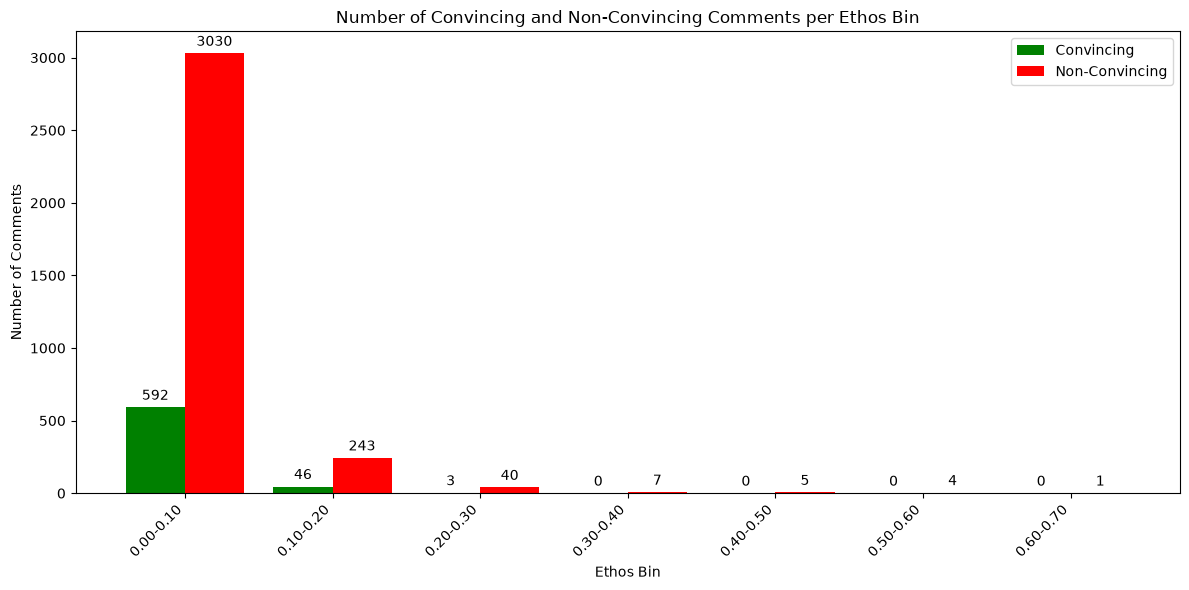

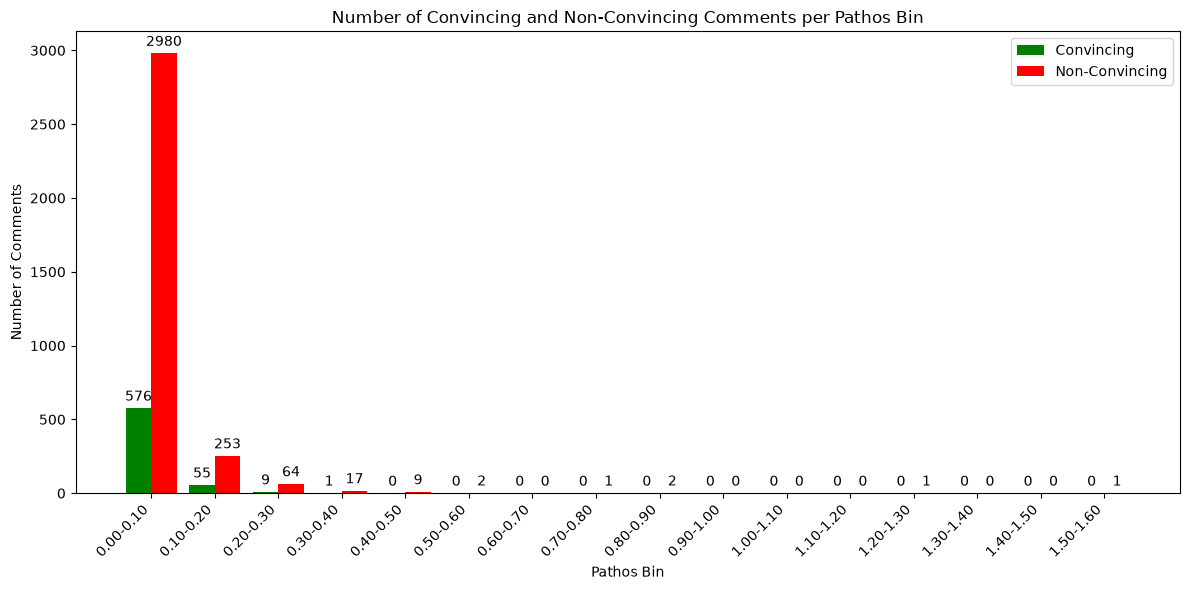

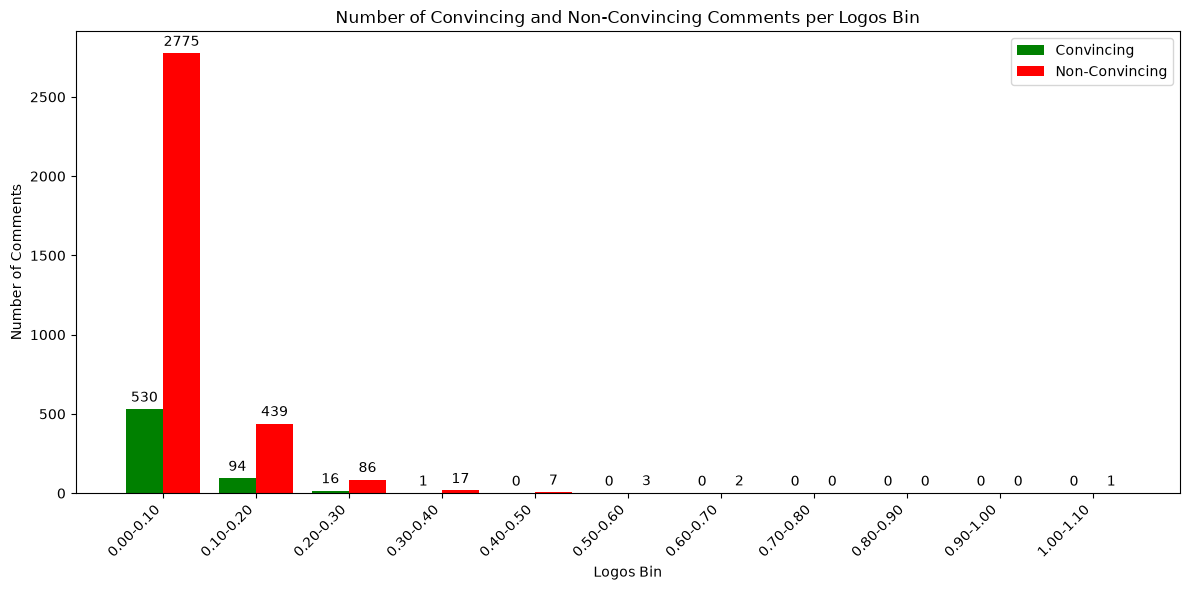

In [ ]:
common_functions.plot_feature(comments_df, 'ethos_score', 'Ethos', 0.10)
common_functions.plot_feature(comments_df, 'pathos_score', 'Pathos', 0.10)
common_functions.plot_feature(comments_df, 'logos_score', 'Logos', 0.10)

Examples:

In [ ]:
MIN_WORDS_FOR_EXAMPLE = 30  # short comments are noisy here: a single matching word can swing the normalized score close to 1.0

def show_rhethorical_mean_example(feature_name, mode='max'):
  candidates = comments_df[comments_df['final_comment'].str.split().str.len() >= MIN_WORDS_FOR_EXAMPLE]
  row = candidates.nlargest(1, feature_name).iloc[0] if mode == 'max' else candidates.nsmallest(1, feature_name).iloc[0]
  # print the same text the score was computed from, not just final_comment - the score can be driven by thread_text too
  text = row['thread_text'] + "\n" + row['final_comment'] if isinstance(row['thread_text'], str) else row['final_comment']
  print(f"{mode.capitalize()} example for {feature_name} = {row[feature_name]:.2f}:")
  print(text)
  print("-" * 20)

for feature in ['ethos_score', 'pathos_score', 'logos_score']:
  show_rhethorical_mean_example(feature, 'max')
  show_rhethorical_mean_example(feature, 'min')


Max example for ethos_score = 0.39:
A sociopath could pass the test and take advantage of the government better than a non scared person can. There are plenty of crooks in the government who know how the government work
--------------------
Min example for ethos_score = 0.00:
Since 3.81 million shares of amazon are traded daily \*as is\* the impact of 4.34 million more per year (17200 per trading day) shouldn't be that large. Also that would be the most he would ever sell, because his net worth would obviously be shrinking

 [https://finbox.com/NASDAQGS:AMZN/explorer/volume\_avg\_3m](https://finbox.com/NASDAQGS:AMZN/explorer/volume_avg_3m)
--------------------
Max example for pathos_score = 0.41:
Disney is part of an Oligopoly.  While not as bad as a Monopoly, it can still be very bad for consumers.  However Disney is pumping out seriously quality movies, better then before they bought all these big companies recently.  
--------------------
Min example for pathos_score = 0.00:
Jeff Be

In [ ]:
baseline_rate = comments_df['is_convincing'].mean()
print(f"Baseline convincing rate: {baseline_rate:.1%}\n")

for feature in ['ethos_score', 'pathos_score', 'logos_score']:
  low = comments_df[comments_df[feature] < 0.10]
  high = comments_df[comments_df[feature] >= 0.10]
  print(f"{feature}: below 0.10 -> {low['is_convincing'].mean():.1%} (n={len(low)}), "
        f"0.10 and above -> {high['is_convincing'].mean():.1%} (n={len(high)})")


Baseline convincing rate: 16.1%

ethos_score: below 0.10 -> 16.3% (n=3622), 0.10 and above -> 14.0% (n=349)
pathos_score: below 0.10 -> 16.2% (n=3556), 0.10 and above -> 15.7% (n=415)
logos_score: below 0.10 -> 16.0% (n=3305), 0.10 and above -> 16.7% (n=666)


With longer comments only (30+ words, so a single matching word can't swing a short comment's normalized score to 1.0), the extreme examples make more intuitive sense: the high-ethos example leans on institutional/authority language, the high-pathos one is emotionally charged, and the high-logos one leans on factual/topical vocabulary, while the low-scoring examples for each are simply comments where none of that category's words happen to appear.

But the convincing-rate breakdown above is what actually settles it. Unlike tone (`Logical` at 24.0% vs. baseline ~16.1%), none of the three scores show a meaningful split: comments at 0.10 or higher land within a couple of points of the ~16% baseline in every case, and those higher bins only hold a few hundred comments each. Empath's category matches are sparse and topic-driven rather than structural - `logos`, for instance, overlaps with subject matter like politics or technology more than with argument quality - so they don't function as a rhetorical-strategy signal here. Rather than drop them outright, we'll mark them as untrusted (the same treatment `sentiment_vader` got) and let `04_model_training.ipynb` decide whether they still carry weak signal - and try an LLM-based version below, the same approach that worked for sentiment and tone.

In [ ]:
untrusted_features.append('ethos_score')
untrusted_features.append('pathos_score')
untrusted_features.append('logos_score')


### LLM-based rhetorical means (Gemini)

Empath's word-list approach conflates *topic* with *rhetorical strategy* - `logos` fires on any mention of politics or technology, regardless of whether the comment is actually reasoning logically, the same problem VADER had with sentiment vs. topic. Let's ask Gemini to rate the degree of each rhetorical appeal directly instead, the same approach that worked for sentiment and tone above.

Setting up the Gemini client and model, the same way `03.1` did for sentiment and tone.

In [ ]:
genai_client = common_functions.make_gemini_client()
GEMINI_MODEL = common_functions.DEFAULT_GEMINI_MODEL
from google.genai import errors as genai_errors

print(f"Using Gemini model: {GEMINI_MODEL}")

In [ ]:
rhetorical_llm_prompt_prefix = common_functions.RHETORICAL_LLM_PROMPT_PREFIX
print(rhetorical_llm_prompt_prefix)

Rate each of the following numbered texts on three rhetorical appeals, each on a scale from 0 (not present) to 1 (strongly present):

- ethos: appeals to the author's credibility, authority, expertise, or character
- pathos: appeals to emotion (sympathy, anger, fear, hope, etc.)
- logos: appeals to logic and reasoning (facts, statistics, cause-and-effect argument)

These are not mutually exclusive - a text can score high on more than one, or low on all three.

Reply with exactly one line per text, in the format "N: ethos,pathos,logos" (matching the numbers below), and nothing else.

Texts:



In [ ]:
comments_df['ethos_llm'] = None
comments_df['pathos_llm'] = None
comments_df['logos_llm'] = None


In [ ]:
import re

def get_rhetorical_llm_batch(rows):
  texts = []
  for row in rows:
    if isinstance(row['thread_text'], str):
      texts.append(row['thread_text'] + "\n" + row['final_comment'])
    else:
      texts.append(row['final_comment'])

  numbered_texts = "\n\n".join(f"{i}:\n{text}" for i, text in enumerate(texts))
  user_prompt = rhetorical_llm_prompt_prefix + numbered_texts
  response = common_functions.generate_content_with_retry(genai_client, GEMINI_MODEL, contents=user_prompt)

  scores = [(None, None, None)] * len(texts)
  for line in response.text.strip().splitlines():
    match = re.match(r'\s*(\d+)\s*[:\-]\s*(-?\d*\.?\d+)\s*,\s*(-?\d*\.?\d+)\s*,\s*(-?\d*\.?\d+)', line)
    if match:
      i = int(match.group(1))
      if 0 <= i < len(scores):
        scores[i] = (float(match.group(2)), float(match.group(3)), float(match.group(4)))
  return scores


In [ ]:
BATCH_SIZE = 20

pending_index = comments_df[comments_df['ethos_llm'].isna()].index
# this loop can be executed multiple times until all entries were classified - each run only retries rows still missing a score
for start in range(0, len(pending_index), BATCH_SIZE):
  batch_index = pending_index[start:start + BATCH_SIZE]
  try:
    scores = get_rhetorical_llm_batch([comments_df.loc[i] for i in batch_index])
    for i, (ethos, pathos, logos) in zip(batch_index, scores):
      comments_df.at[i, 'ethos_llm'] = ethos
      comments_df.at[i, 'pathos_llm'] = pathos
      comments_df.at[i, 'logos_llm'] = logos
    comments_df.to_csv('../results/comments_df_rhetorical_llm_checkpoint.csv', index=False)
    print(f"scored rows {batch_index[0]}-{batch_index[-1]}")
  except genai_errors.ClientError as e:
    print(f"batch {batch_index[0]}-{batch_index[-1]} failed: {e}")
    print("this looks like a quota error, not a transient one - further batches today would just fail too. stopping; re-run this cell after the quota resets.")
    break
  except Exception as e:
    print(f"batch {batch_index[0]}-{batch_index[-1]} failed, will retry on next run: {e}")


In [ ]:
for feature in ['ethos_llm', 'pathos_llm', 'logos_llm']:
  none_count = comments_df[feature].isna().sum()
  if none_count == 0:
    print(f"{feature}: all entries were classified!")
  else:
    print(f"{feature}: {none_count} entries still need to be classified out of {len(comments_df)}")
  comments_df[feature] = pd.to_numeric(comments_df[feature], errors='coerce')


ethos_llm: all entries were classified!
pathos_llm: all entries were classified!
logos_llm: all entries were classified!


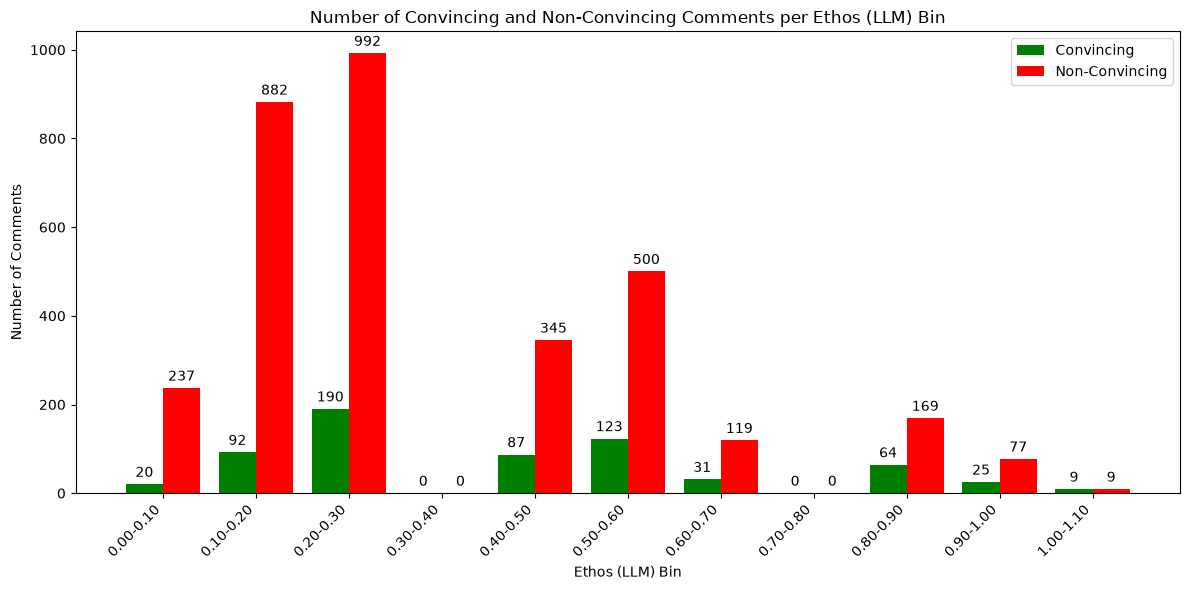

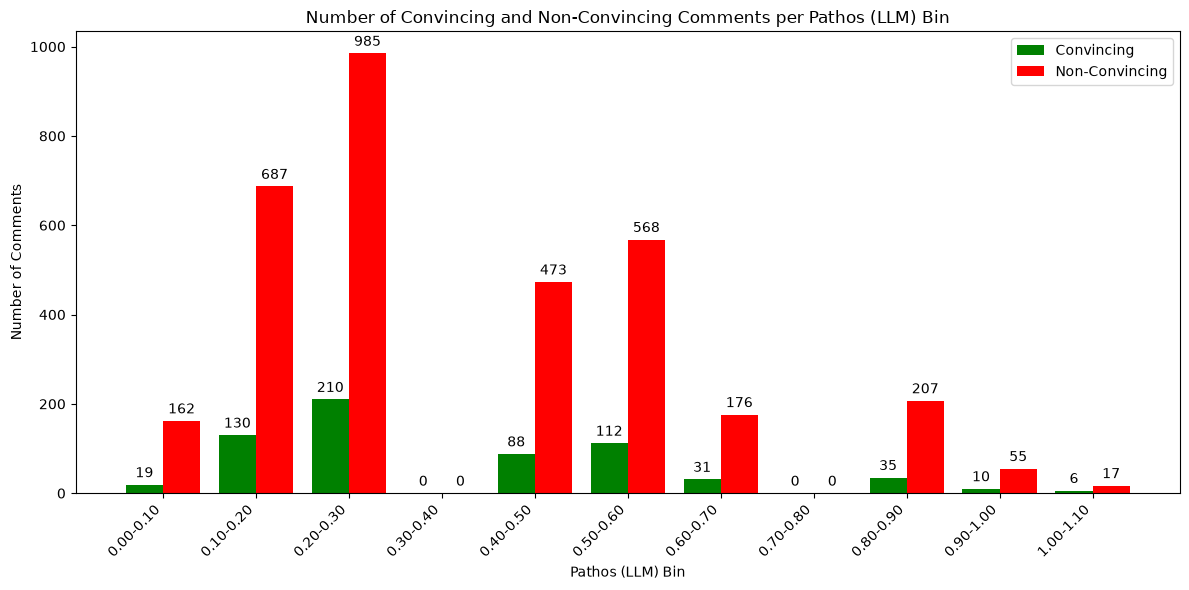

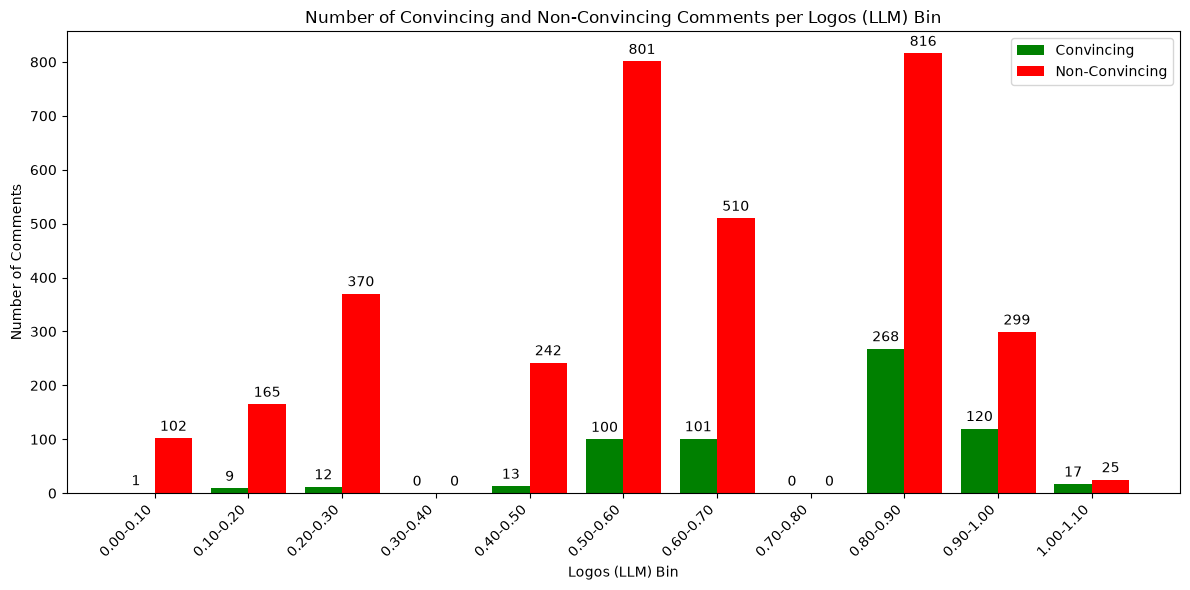

In [ ]:
common_functions.plot_feature(comments_df, 'ethos_llm', 'Ethos (LLM)', 0.10)
common_functions.plot_feature(comments_df, 'pathos_llm', 'Pathos (LLM)', 0.10)
common_functions.plot_feature(comments_df, 'logos_llm', 'Logos (LLM)', 0.10)


In [ ]:
def show_rhetorical_llm_example(feature_name, mode='max'):
  row = comments_df.nlargest(1, feature_name).iloc[0] if mode == 'max' else comments_df.nsmallest(1, feature_name).iloc[0]
  text = row['thread_text'] + "\n" + row['final_comment'] if isinstance(row['thread_text'], str) else row['final_comment']
  print(f"{mode.capitalize()} example for {feature_name} = {row[feature_name]:.2f}:")
  print(text)
  print("-" * 20)

for feature in ['ethos_llm', 'pathos_llm', 'logos_llm']:
  show_rhetorical_llm_example(feature, 'max')
  show_rhetorical_llm_example(feature, 'min')


Max example for ethos_llm = 1.00:
The low hanging issue is that these news networks claim that what they spout is not "news", but "entertainment".

Despite being a news network.

There's gotta be a way to close that loophole at least.

Here's an article that addresses exactly what you're referring to: https://www.npr.org/2020/09/29/917747123/you-literally-cant-believe-the-facts-tucker-carlson-tells-you-so-say-fox-s-lawye

This has been raised for Tucker Carlson and Rachel Maddow, both of whom were deemed to be clearly lying in the eyes of a "reasonable viewer".

Of course the words "clearly lying" aren't used. They are replaced with words like "rhetoric", "hyperbole", "exaggeration", "non-literal", "commentary", and "figurative".

If there's no law preventing figurative and hyperbolic commentary from talking heads (sure, that's fine), maybe we should consider forcing them to make that distinction apparent. 

Their entire legal argument is grounded on the expectation of "reasonable view

In [ ]:
baseline_rate = comments_df['is_convincing'].mean()
print(f"Baseline convincing rate: {baseline_rate:.1%}\n")

for feature in ['ethos_llm', 'pathos_llm', 'logos_llm']:
  low = comments_df[comments_df[feature] < 0.5]
  high = comments_df[comments_df[feature] >= 0.5]
  print(f"{feature}: below 0.5 -> {low['is_convincing'].mean():.1%} (n={len(low)}), "
        f"0.5 and above -> {high['is_convincing'].mean():.1%} (n={len(high)})")


Baseline convincing rate: 16.1%

ethos_llm: below 0.5 -> 13.7% (n=2845), 0.5 and above -> 22.4% (n=1126)
pathos_llm: below 0.5 -> 16.2% (n=2754), 0.5 and above -> 15.9% (n=1217)
logos_llm: below 0.5 -> 3.8% (n=914), 0.5 and above -> 19.8% (n=3057)


The three scores landed very differently once measured directly instead of through Empath's word lists.

`logos_llm` shows the widest split we've seen in this notebook: comments scoring below 0.5 convince only 3.8% of the time (n=915), while those at 0.5 or above convince 19.8% of the time (n=3057) - a ~5.2x gap between the two bins, wider than `tone_google`'s `Logical` vs. `Sarcastic` split (3.4x). It also fixes the exact problem `logos_score` had: rather than firing on any mention of politics or technology, it tracks genuine reasoning - the max-scoring example is a long, well-sourced rebuttal that walks through a study's methodology and conclusions, while the min-scoring example is a one-line "hear hear" reply with no argument at all.

`ethos_llm` shows a real but smaller split: 13.7% convincing below 0.5 (n=2846) vs. 22.4% at or above (n=1126). (The highest-scoring example here used to be an automated moderator "thread locked" notice rather than real author content - see the data-quality-check cells in `02_data_annotation.ipynb` - now removed at the source. The current top example is a comment arguing that news networks shouldn't get to hide behind "commentary" framing to dodge accountability, which reads as a genuine credibility/accountability appeal.)

`pathos_llm` is essentially flat (16.2% vs. 15.9%, against a ~16.1% baseline) - emotional appeal on its own doesn't seem to predict persuasiveness here, the same conclusion we reached for `sentiment_llm` and VADER. We'll keep it as a feature anyway rather than marking it untrusted outright, in case a non-linear or combined effect shows up once the model sees it alongside the others.

## 6.5 Adjective-Adverb Ratio

The **Adjective-Adverb Ratio**, also called the **Descriptive Density Ratio** measures the proportion of adjectives and adverbs in a text relative to the total word count. A higher ratio indicates a more expressive or emotionally charged writing style, while a lower ratio suggests a more concise, factual, and objective tone.

In [ ]:
!pip install spacy
!python -m spacy download en_core_web_sm

In [ ]:
import inspect
print(inspect.getsource(common_functions.get_adjective_adverb_ratio))

get_adjective_adverb_ratio = common_functions.get_adjective_adverb_ratio

def get_adjective_adverb_ratio(text):
    doc = _get_nlp()(text)
    adjectives = [token.text for token in doc if token.pos_ == 'ADJ']
    adverbs = [token.text for token in doc if token.pos_ == 'ADV']
    return len(adjectives) / len(adverbs) if len(adverbs) > 0 else np.inf



In [ ]:
comments_df['adj_adv_ratio'] = None

In [ ]:
import numpy as np
common_functions.do_calc_feature(comments_df, "adj_adv_ratio", get_adjective_adverb_ratio)

We want to plot the results. Rows with no adverbs get an infinite ratio, which isn't usable for plotting or stats, so we cap them at a sentinel value just above the observed finite max. A small margin keeps these rows ranked as the highest without an oversized value skewing the chart's scale or the mean/std.

In [ ]:
finite_max = comments_df['adj_adv_ratio'].replace(np.inf, np.nan).max()
sentinel = finite_max + 2  # small margin above the real max keeps infinite-ratio rows the highest without distorting the plot

print("The finite max of adj_adv_ratio is:", finite_max)
print("The sentinel value for infinite ratios is:", sentinel)

The finite max of adj_adv_ratio is: 15.0
The sentinel value for infinite ratios is: 17.0


In [ ]:
comments_df['adj_adv_ratio'] = comments_df['adj_adv_ratio'].replace(np.inf, sentinel).astype(float)

comments_df.to_csv('../results/comments_df_adj_adv_ratio_checkpoint.csv', index=False)

A value of `sentinel` (currently 17.0, printed above) is not a real measurement — it marks a comment that has at least one adjective but zero adverbs, where the true ratio is undefined (division by zero, i.e. mathematically infinite). We cap all such comments at the same fixed sentinel purely so the column stays plottable and comparable; it should be read as "infinite/undefined ratio", not as "17 times more adjectives than adverbs".

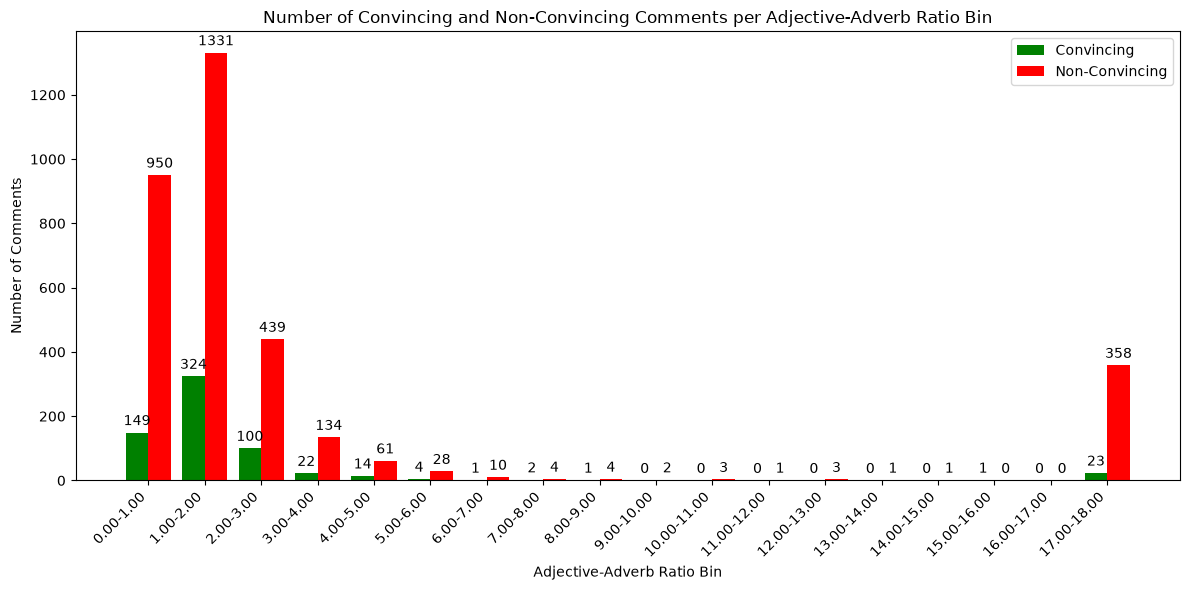

In [ ]:
common_functions.plot_feature(comments_df, 'adj_adv_ratio', 'Adjective-Adverb Ratio', 1)

In [ ]:
import numpy as np

# "Infinite" ratio: at least one adjective, zero adverbs detected - capped at `sentinel` (see explanation above)
infinite_ratio_rows = comments_df[comments_df['adj_adv_ratio'] == sentinel]
infinite_example_row = infinite_ratio_rows.iloc[0]
print(f"Example for 'infinite' Adj/Adv ratio (capped at {sentinel}, {len(infinite_ratio_rows)} such comments in the dataset):")
print(infinite_example_row['final_comment'])
print("-" * 20)

# Highest genuinely finite ratio (excludes the capped 'infinite' rows)
finite_ratio_rows = comments_df[comments_df['adj_adv_ratio'] < sentinel]
max_finite_row = finite_ratio_rows.loc[finite_ratio_rows['adj_adv_ratio'].idxmax()]
print(f"Example for highest finite Adj/Adv ratio ({max_finite_row['adj_adv_ratio']}):")
print(max_finite_row['final_comment'])
print("-" * 20)

min_adj_adv_ratio_row = comments_df.loc[comments_df['adj_adv_ratio'].idxmin()]
print(f"Example for low Adj/Adv ratio ({min_adj_adv_ratio_row['adj_adv_ratio']}):")
print(min_adj_adv_ratio_row['final_comment'])
print("-" * 20)


Example for 'infinite' Adj/Adv ratio (capped at 17.0, 382 such comments in the dataset):
Sure it does.  And he doesn't have to sell it for it to become liquid capital.  He can go to any bank like JPM and borrow against it at a low %, buy whatever the fuck he wants and not pay capital gains etc.  The "stock isn't realized capital" argument is bullshit when you look at how billionaires leverage their net worth.
--------------------
Example for highest finite Adj/Adv ratio (15.0):
Depends where you look. on a macro/resource level you have a point.

But if you look at countries like Japan their issue is they have such an old population, and there isn't enough young people to do all the necessary jobs to look after the elderly.

A lot of western countries are facing similar impending crisis. Mainly around how populations are aging and there isn't enough money in pension pots to support them.

Whilst it may seem good the population as a whole is decreasing. The birth rate decreasing comes wi

Generally, we can say that:
* High Adjective-to-Adverb Ratio
  * More adjectives than adverbs
  * The text is descriptive and vivid, often used in storytelling and persuasive writing to create strong imagery and appeal to emotions.
  * May indicate a focus on ethos (credibility) and pathos (emotion) by painting a compelling picture.

* Low Adjective-to-Adverb Ratio
  * More adverbs than adjectives
  * The text is action-driven and dynamic, emphasizing how actions are performed, often found in arguments, speeches, or instructional writing.
  * May indicate a focus on logos (logical reasoning) and pathos (emotional appeal) by emphasizing how actions happen.

* Balanced Ratio
  * More or less the same amount of adjectives and adverbs
  * The text is neutral and precise, commonly seen in academic, formal, or news writing, aiming for a mix of credibility, logic, and emotional appeal.
  * May indicate a mix of ethos (credibility), logos (logic), and pathos (emotion) in persuasion.



We see that in our dataset, the texts tend to have high ratio of Adjective-to-Adverb.

In [ ]:
overall_rate = comments_df['is_convincing'].mean()
infinite_rate = comments_df.loc[comments_df['adj_adv_ratio'] == sentinel, 'is_convincing'].mean()
rest_rate = comments_df.loc[comments_df['adj_adv_ratio'] < sentinel, 'is_convincing'].mean()

print(f"Overall convincing rate: {overall_rate:.1%}")
print(f"Convincing rate among 'infinite' ratio comments (zero adverbs): {infinite_rate:.1%}")
print(f"Convincing rate among comments with a measurable (finite) ratio: {rest_rate:.1%}")


Overall convincing rate: 16.1%
Convincing rate among 'infinite' ratio comments (zero adverbs): 6.0%
Convincing rate among comments with a measurable (finite) ratio: 17.2%


The bar chart's raw counts are dominated by the overall class imbalance (non-convincing comments outnumber convincing ones throughout), which can hide whether the ratio itself relates to persuasiveness. Looking at the convincing rate instead of raw counts, the "infinite" ratio group (zero adverbs, `~9.6%` of all comments) stands out: its convincing rate is roughly a third of the rate seen among comments with a measurable ratio (~6% vs. ~17%, against an overall average of ~16%). This suggests that comments written with no adverbs at all - often short, blunt, unhedged statements - tend to be less persuasive, while the moderate ratio bins (which hold almost all of the data) don't show a strong trend among themselves.


## 6.6 Readability

Readability is a crucial feature in the feature engineering of convincing and non-convincing texts because it directly impacts how easily the audience can understand and engage with the message. A highly readable text is often more persuasive, as it allows the reader to quickly grasp the key points and emotional appeals without feeling overwhelmed or lost in complex language.

One of the widely used metrics for estimating readability is the **Flesch-Kincaid Readability Tests**.

The **Flesch-Kincaid Readability Tests** provide a score based on sentence length and word complexity, with the result indicating the U.S. school grade level required to understand the text. A lower score suggests a more accessible text, which is often more persuasive.

We will calculate:
* Flesch-Kincaid Grade Level: This score gives an approximation of the U.S. school grade level needed to understand the text. A higher value means more complex language.
* Flesch Reading Ease: This score indicates how easy the text is to read. Higher values (above 60) indicate easier text, while lower values suggest more complex, harder-to-read text.

In [ ]:
!pip install textstat

### Flesh Kincaid Grade Level

In [ ]:
comments_df['fk_grade_level'] = None

In [ ]:
import textstat
common_functions.do_calc_feature(comments_df, "fk_grade_level", lambda text: textstat.flesch_kincaid_grade(text), remove_urls=True)

In [ ]:
comments_df['fk_grade_level'].head()

0      10.295
1    7.934588
2       -1.45
3    8.091111
4    8.806096
Name: fk_grade_level, dtype: object

The datatype is object, we will convert it to a number.

In [ ]:
comments_df['fk_grade_level_converted'] = pd.to_numeric(comments_df['fk_grade_level'], errors='coerce')

In [ ]:
comments_df['fk_grade_level_converted'].describe()

count    3971.000000
mean        9.121506
std         3.717330
min        -3.400000
25%         7.033082
50%         8.957923
75%        11.059985
max        44.190000
Name: fk_grade_level_converted, dtype: float64

We see that there's an unexpected result of -3.4 in the minimum, let's inspect the comments that resulted a value below 0:

In [ ]:
comments_df[comments_df['fk_grade_level_converted'] < 0]['final_comment']

2       I saved your post it was so good. Hear hear to...
330                                             Good bot.
337                                              It’s not
402                   RIP, man. Seemed like a great dude.
432                             This is a great point tbh
453                                              Hot take
545                                                   YES
620                                         That's fucked
732     [Cardale Jones ain’t come here to play school....
790                                       You are wrong. 
830                                               Source?
897     OP.  Watch them clash.  And they all swear to ...
935                         That's a good ass song though
1083                                           Great take
1084                    Yup to both of yall! I 100% agree
1139                                  Will give it a read
1210                          I find peace in long walks.
1351          

We see that these are very short texts with very few syllables, so the result is expected. Let's inspect the distribution.

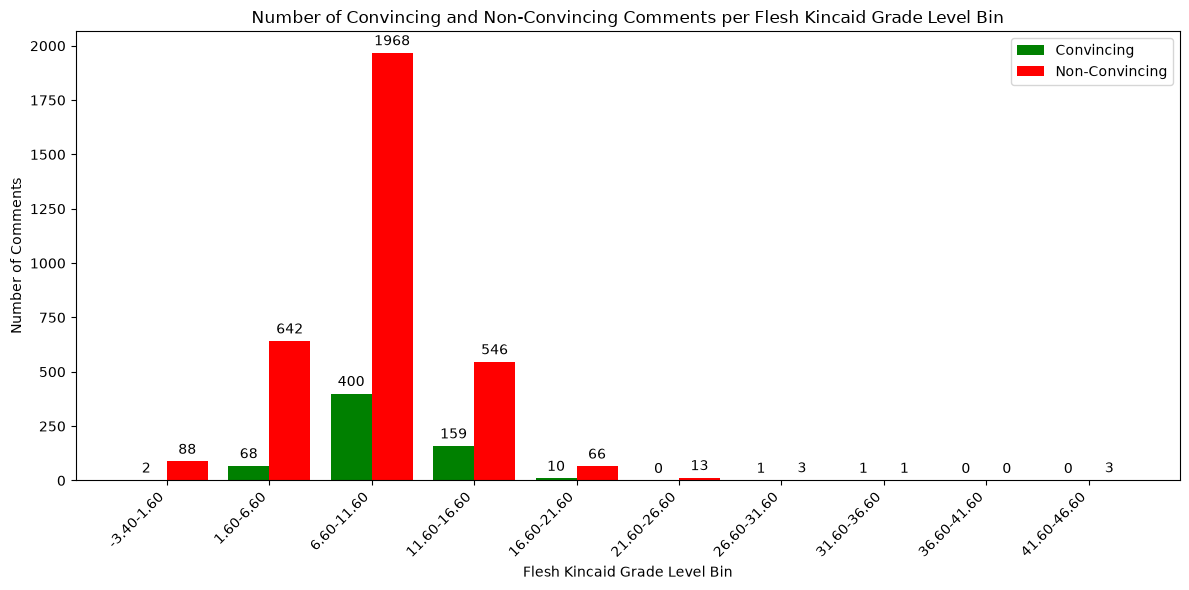

In [ ]:
common_functions.plot_feature(comments_df, 'fk_grade_level_converted', 'Flesh Kincaid Grade Level', 5)

The convincing rate isn't monotonic with grade level. Very simple comments (grade -3.4 to 1.6, ~90 comments) convince only ~2% of the time, and the low-complexity range up to grade ~6.6 sits at ~10% - both well under the ~16% overall average. The rate climbs through the bulk of the data (grade 6.6-11.6, ~60% of all comments) to ~17%, and peaks in the grade 11.6-16.6 range at ~23%, noticeably more persuasive than average. Past grade ~17 it falls again, and grades above ~20 have only a handful of comments each - too few to draw a conclusion. So there's a real sweet spot around high-school-to-early-college complexity, while very simple, short comments are the least persuasive group on this feature.

In [ ]:
comments_df['fk_grade_level'] = comments_df['fk_grade_level_converted']
comments_df.drop(columns=['fk_grade_level_converted'], inplace=True)

In [ ]:
example_targets = [0, 5, 9, 14, 18]
for target in example_targets:
    candidates = comments_df[
        comments_df['fk_grade_level'].between(target - 0.3, target + 0.3) &
        comments_df['final_comment'].str.len().between(60, 260)
    ]
    if len(candidates):
        row = candidates.iloc[0]
        print(f"Example near grade level {target} (actual: {row['fk_grade_level']:.2f}):")
        print(row['final_comment'])
        print("-" * 20)

max_grade_level_row = comments_df.loc[comments_df['fk_grade_level'].idxmax()]
print(f"Example for high FK grade level ({max_grade_level_row['fk_grade_level']:.2f}):")
print(max_grade_level_row['final_comment'])
print("-" * 20)


Example near grade level 0 (actual: -0.08):
OP.  Watch them clash.  And they all swear to know the TRUTH.  Must be nice to be so confident.
--------------------
Example near grade level 5 (actual: 4.88):
If it's "parked" in an account then it's fueling the economy through lending. The only way for money to be "parked" is if you take a wad of cash and put it into a safe. No sane man would do that due to inflation.
--------------------
Example near grade level 9 (actual: 9.09):
And the good parts for most people are temporary - the tax breaks for corporations are permanent.
--------------------
Example near grade level 14 (actual: 14.25):
How dare you Venezuela is a utopia and anything that says otherwise is capitalist propaganda.  /s
--------------------
Example near grade level 18 (actual: 17.86):
If you are eliminating the current private sector entirely and installing a single government entity in its stead that is the definition of “nationalization”.
--------------------
Example for

### Flesh Kincaid Reading Ease

In [ ]:
comments_df['fk_reading_ease'] = None

In [ ]:
common_functions.do_calc_feature(comments_df, "fk_reading_ease", lambda text: textstat.flesch_reading_ease(text), remove_urls=True)

In [ ]:
comments_df['fk_reading_ease'].head()

0     61.327500
1     62.398647
2    116.145000
3     63.770000
4     57.308092
Name: fk_reading_ease, dtype: float64

In [ ]:
comments_df['fk_reading_ease'] = pd.to_numeric(comments_df['fk_reading_ease'], errors='coerce')

In [ ]:
comments_df['fk_reading_ease'].describe()

count    3971.000000
mean       61.089182
std        18.761663
min      -218.195000
25%        52.307500
50%        61.633891
75%        70.418749
max       121.220000
Name: fk_reading_ease, dtype: float64

Like the grade level minimum above, reading ease also has a long tail of very low (negative) scores. Let's inspect the comments below -20:

In [ ]:
comments_df[comments_df['fk_reading_ease'] < -20]['final_comment']

869                                        self-sabotage.
1013                       "analyzational"\n\nAnalytical?
1088                               Abortion is euthanasia
1917                                     /r/TheMonkeysPaw
2018    > There are communities where [American Evange...
2510          Logistics, logistics, logistics, logistics.
2742    Asinine comparison. Canada's freshwater resour...
3054                              Reenactment organizers.
3392                              /r/SuspiciouslySpecific
3848                     Please define "Over-regulation".
Name: final_comment, dtype: str

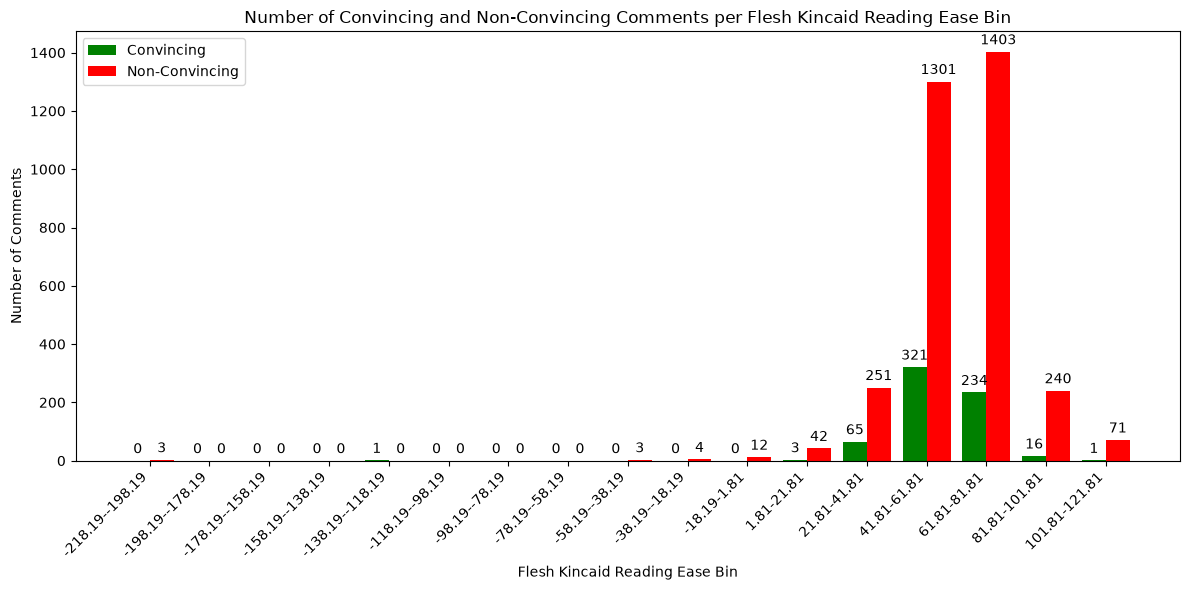

In [ ]:
common_functions.plot_feature(comments_df, 'fk_reading_ease', 'Flesh Kincaid Reading Ease', 20)

Reading ease shows roughly the mirror image of the grade-level pattern (the two metrics are inversely related by construction). Both tails underperform: the hardest-to-read comments (ease below ~20, mostly very short comments packed with rare or long words - see the inspection above) convince at ~7% or less, and the easiest-to-read comments (ease above ~80, i.e. very short and simplistic) convince at only ~6%, dropping to ~1% at the very easiest bucket. The bulk of the data (ease 42-82, over 80% of comments) sits in between, and even there the moderately-harder half (42-62, ~20% convincing) out-converts the easier half (62-82, ~14% convincing). As with grade level, moderate difficulty - neither too simple nor too complex - is associated with the highest persuasion rate.

In [ ]:
min_row = comments_df.loc[comments_df['fk_reading_ease'].idxmin()]
print(f"Example for very low FK reading ease ({min_row['fk_reading_ease']:.2f}):")
print(min_row['final_comment'])
print("-" * 20)

max_ease = comments_df['fk_reading_ease'].max()
max_rows = comments_df[comments_df['fk_reading_ease'] == max_ease]
print(f"Example for very high FK reading ease ({max_ease:.2f}, {len(max_rows)} comments tied at this score):")
print(max_rows.iloc[0]['final_comment'])
print("-" * 20)

# Examples from the two most common buckets, for contrast with the extremes above
common_bucket_targets = [55, 70]
for target in common_bucket_targets:
    candidates = comments_df[
        comments_df['fk_reading_ease'].between(target - 3, target + 3) &
        comments_df['final_comment'].str.len().between(80, 260)
    ]
    if len(candidates):
        row = candidates.iloc[0]
        print(f"Example near reading ease {target} (actual: {row['fk_reading_ease']:.2f}):")
        print(row['final_comment'])
        print("-" * 20)


Example for very low FK reading ease (-218.19):
"analyzational"

Analytical?
--------------------
Example for very high FK reading ease (121.22, 5 comments tied at this score):
YES
--------------------
Example near reading ease 55 (actual: 57.95):
There certainly are other arguments against it. But if a plan isn't achievable, I'd say that's problem #1 with the plan.
--------------------
Example near reading ease 70 (actual: 72.27):
The other thing is that your view is really not a useful one. You can always find a technically positive small piece of a large bill and then say he's doing good. But the only real way to evaluate his impact is holistically.
--------------------


In [ ]:
comments_df.to_csv('../results/comments_df_readability_checkpoint.csv', index=False)

## 6.7 Use of Evidence

The paper, "[Attitude Change on Reddit's Change My View](https://jpriniski.github.io/papers/cogsci-reddit.pdf)," explores how individuals on the Reddit forum **Change My View (CMV)** adjust their beliefs on various topics, particularly focusing on sociomoral issues (e.g., politics, morality) compared to non-sociomoral topics (e.g., humor, fiction).

The studuy includes the code for calculating evidence use in comments. We will adapt the code from their [repo in GitHub](https://github.com/jpriniski/CMV), and execute it on our own dataset, to create the evidence use features.

`evidence_count` is a simple keyword-stem heuristic, adapted from the paper's own method: it stems every word in the thread + comment text and counts how many match a fixed list of stems associated with citing data or documented facts (`stat`, `percent`, `figur`, `evid`, `document`, `measur`, `\$`, `million`, comparison words like `greater`/`less`, and similar). A **high** value means the comment leans heavily on numbers, statistics, or references to documented/measurable facts to make its case; a **low** value (0 is both the mode and median - about 63% of comments score 0) means the argument is built on reasoning, opinion, or anecdote without citing anything quantifiable. It's a surface-level lexical count, not real fact-checking - a comment can score high by discussing money or percentages loosely, without actually citing a source.

In [ ]:
print("EVIDENCE_STEMS:", common_functions.EVIDENCE_STEMS)
print("EVIDENCE_URL_EXTENSIONS:", common_functions.EVIDENCE_URL_EXTENSIONS)
print()
import inspect
print(inspect.getsource(common_functions.get_evidence_count))

get_evidence_count = common_functions.get_evidence_count

EVIDENCE_STEMS: ['data', 'stat', 'statist', 'figur', '%', 'percent', 'averag', 'number', 'amount', 'thousand', 'million', 'billion', '$', '€', '¥', '£', 'dollar', 'evid', 'info', 'testimoni', 'conclus', 'document', 'experi', 'experi', 'measur', 'measur', 'report', 'result', 'census', 'figur', 'plot', 'graph', 'sum', 'total', 'decim', 'digit', 'fraction', 'numer', 'half', 'share', 'proport', 'capit', 'cash', 'properti', 'salari', 'wage', 'wealth', 'financ', 'resourc', 'roll', 'treasuri', 'bank', 'deposit', 'exchang', 'safe', 'estim', 'price', 'price', 'merchandis', 'retail', 'sale', 'cartel', 'invest', 'market', 'deposit', 'document', 'indic', 'wit', 'affirm', 'corrobor', 'declar', 'good', 'ground', 'token', 'signific', 'probabl', 'p valu', '<', '=', 'greater', 'equal', 'less', 'rang', 'devi', 'sd', 'mode', 'median']
EVIDENCE_URL_EXTENSIONS: ['http://', 'https://', '.com', '.org', '.gov', 'pdf', '.net', 'www.']

def get_evidence_count(text):
    evidence_count = 0
    comment_stemmed = 

In [ ]:
comments_df['evidence_count'] = None

In [ ]:
common_functions.do_calc_feature(comments_df, "evidence_count", get_evidence_count)

In [ ]:
comments_df['evidence_count'].describe()

count     3971
unique      21
top          0
freq      2512
Name: evidence_count, dtype: int64

In [ ]:
comments_df['evidence_count'] = pd.to_numeric(comments_df['evidence_count'])

In [ ]:
comments_df['evidence_count'].describe()

count    3971.000000
mean        0.869302
std         1.911464
min         0.000000
25%         0.000000
50%         0.000000
75%         1.000000
max        31.000000
Name: evidence_count, dtype: float64

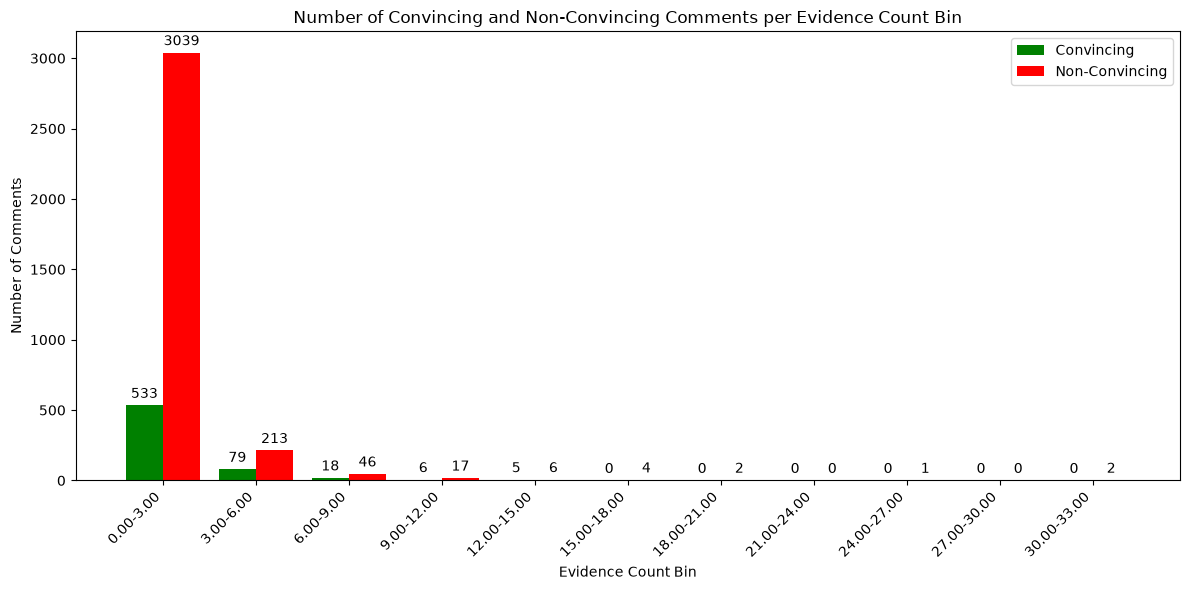

In [ ]:
common_functions.plot_feature(comments_df, 'evidence_count', 'Evidence Count', 3)

Unlike grade level and reading ease, this feature shows a clean, roughly monotonic relationship with persuasion. Comments with no evidence markers at all (evidence_count=0, ~63% of the data) convince only ~12.5% of the time - well below the ~16% overall average. The rate jumps to ~19% with just one evidence marker, and climbs further to ~23-29% from two markers onward, settling around ~25-28% for anything beyond that. So citing even a little bit of data or documented fact is associated with meaningfully higher persuasiveness than citing none - though it isn't a guarantee: the two comments tied for the highest score in the whole dataset (evidence_count=31) were both non-convincing, so a heavy use of these keywords alone doesn't automatically make an argument work.

In [ ]:
max_evidence = comments_df['evidence_count'].max()
max_rows = comments_df[comments_df['evidence_count'] == max_evidence]
print(f"Example for high evidence count ({max_evidence:.0f}, {len(max_rows)} comments tied at this score):")
print(max_rows.iloc[0]['thread_text'])
print(max_rows.iloc[0]['final_comment'])
print("-" * 20)

# Contrast: a typical comment with no evidence markers at all (the mode - about 63% of comments)
no_evidence_row = comments_df[comments_df['evidence_count'] == 0].iloc[10]
print(f"Example for no evidence at all (evidence_count=0):")
print(no_evidence_row['final_comment'])
print("-" * 20)


Example for high evidence count (31, 2 comments tied at this score):
2. I think it's good to use other countries as a barometer for how much we spend. As a percentage of GDP we spend less than Russia and Saudi Arabia. As a total amount of spending we spend slightly more than Saudi Arabia, Russia, and China combined. The amounts the rest of NATO spends is negligible by comparison. We are spending like 10-20% more than would equal out to all of these countries but that's forgetting that we are fighting very real conflicts around the world. We can reduce our military spending but other NATO countries need to start pulling their own weight before we do.

3. The Military Industrial complex is very important. Part of the reason our economy does well is we're pumping money into it via military spending. The money that goes into making bullets and missiles doesn't evaporate when the they're fired, it goes into the pockets of US defense contractors. When our equipment gets old we sell it off to

In [ ]:
comments_df.to_csv('../results/comments_df_evidence_checkpoint.csv', index=False)

## 6.8 Use of Persuasive Language

We want to identify if the comment and context include use of persuasive language. To do this, we will use a HuggingFace model: https://huggingface.co/chreh/persuasive_language_detector.

From the model card:
> Given a sentence, our model predicts whether or not the sentence contains "persuasive" language, or language designed to elicit emotions or change readers' opinions. The model was tuned on the SemEval 2020 Task 11 dataset. However, we preprocessed the dataset to adapt it from multilabel technique classification and span-classification to our binary classification task.

The model has two flavours, BERT and XLM-RoBERTa. Based on the documentation, the latter performs better and faster, so we will use it.

**GPU note:** the persuasive language classification cells below need a GPU to run in reasonable time. If you don't have one locally, run them in [Colab](https://colab.research.google.com/) with a GPU runtime:

1. Upload this notebook to Colab (File → Upload notebook).
2. Set the runtime to GPU (Runtime → Change runtime type → GPU).
3. Upload the checkpoint file saved above (`../results/comments_df_evidence_checkpoint.csv`) via the Files pane on the left.
4. Run the cell below to load the checkpoint, then continue running the notebook from here.

In [1]:
import pandas as pd

comments_df = pd.read_csv(f'/content/comments_df_evidence_checkpoint.csv')

print(f'Loaded checkpoint: comments_df ({len(comments_df)} rows)')

Loaded checkpoint: comments_df (3971 rows)


In [ ]:
from transformers import AutoModelForSequenceClassification, AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained("xlm-roberta-base")
model = AutoModelForSequenceClassification.from_pretrained("chreh/persuasive_language_detector", revision="roberta")


In [4]:
import torch

max_length = 512
def classify_text(text):
    # The model gets only up to 512 tokens
    inputs = tokenizer(text, return_tensors="pt", truncation=True, padding=True, max_length=max_length)

    with torch.no_grad():
        outputs = model(**inputs)

    logits = outputs.logits
    predicted_class = torch.argmax(logits, dim=1).item()

    return predicted_class


In [5]:
text = comments_df.iloc[0]['final_comment']
classify_text(text)

1

In [6]:
text

"Δ You're completely [right](https://smallbusiness.chron.com/deductions-supplies-make-products-vs-inventory-81304.html). Huh. Interesting."

The model card doesn't document which class label (`0` or `1`) means "persuasive" - the result above for this short, non-persuasive-sounding text is a good reason to check that before trusting the batch run below. Testing on two unambiguous examples:

In [12]:
print("Clearly persuasive example:", classify_text(
    "You absolutely must act now — this is the only way to save our future, and anyone who thinks otherwise simply hasn't looked at the facts."
))
print("Clearly neutral/factual example:", classify_text("The meeting is scheduled for 3pm on Tuesday."))

Clearly persuasive example: 1
Clearly neutral/factual example: 0


The label mapping checks out on the two unambiguous examples above, so row 0's `1` wasn't a labeling bug - just the model being unreliable on a very short, 6-word input, similar to what we saw with `tone_label` in `03.1`. One anecdotal misfire isn't enough to judge the feature either way, so let's apply it on all rows and decide whether to trust it the same way we did for every other feature: by checking the convincing-rate correlation and looking at examples, not by a single spot-check.

In [7]:
comments_df['use_of_persuasive_lang'] = None

In [ ]:
common_functions.do_calc_feature(comments_df, "use_of_persuasive_lang", classify_text, switch_order=True)

Now we store the file in Google Drive. Then we can download the file from there and continue locally.

In [11]:
# store in Google Drive:
try:
    from google.colab import drive
    drive.mount('/content/drive')

    # any path under /content/drive/MyDrive/... is now just a normal filesystem path
    drive_dir = '/content/drive/MyDrive'

    comments_df.to_csv(f'{drive_dir}/comments_df_persuasive_lang_checkpoint.csv', index=False)

    print(f'Saved checkpoint to {drive_dir}')
except ImportError:
    print("Not in Colab!")

Mounted at /content/drive
Saved checkpoint to /content/drive/MyDrive


In [13]:
# Load the checkpoint locally:
comments_df = pd.read_csv('../results/comments_df_persuasive_lang_checkpoint.csv')
print("Loaded from checkpoint!")

Loaded from checkpoint!


In [14]:
comments_df['use_of_persuasive_lang']

0       1
1       1
2       0
3       1
4       1
       ..
3966    1
3967    1
3968    0
3969    1
3970    1
Name: use_of_persuasive_lang, Length: 3971, dtype: int64

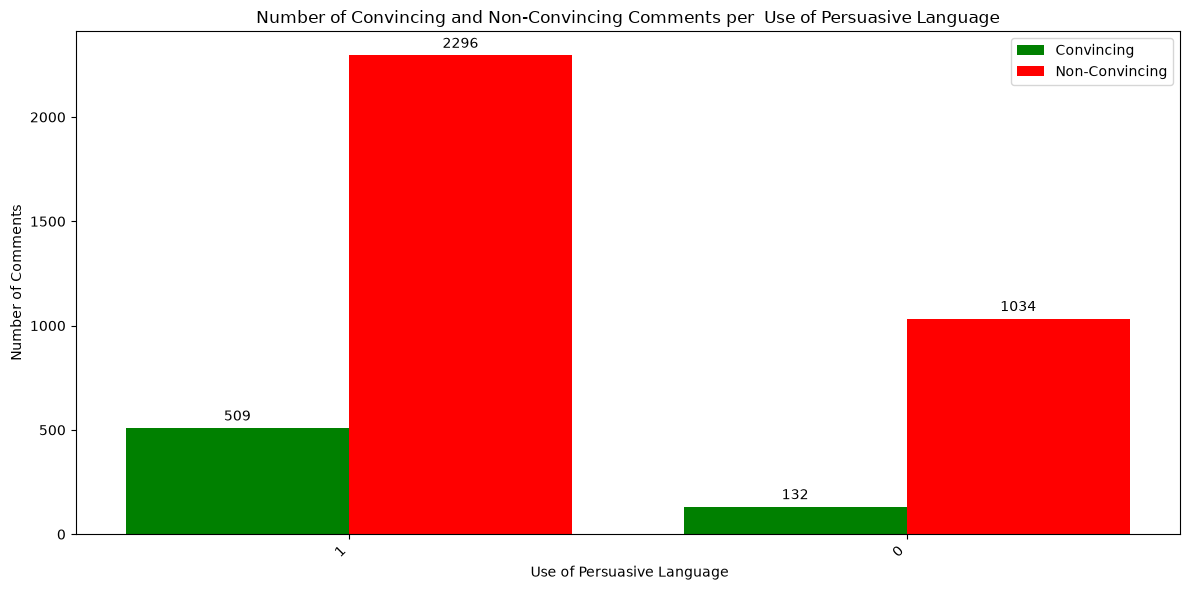

In [15]:
common_functions.plot_category_histogram(comments_df, 'use_of_persuasive_lang', ' Use of Persuasive Language')

Examples:

In [18]:
MIN_WORDS_FOR_EXAMPLE = 30  # short comments (like the 6-word example above) don't give the model enough to work with

long_comments = comments_df[comments_df['final_comment'].str.split().str.len() >= MIN_WORDS_FOR_EXAMPLE]

persuasive_example = long_comments[long_comments['use_of_persuasive_lang'] == 1].iloc[0]
print("Example classified as persuasive (1):")
print(persuasive_example['final_comment'])
print("-" * 20)

non_persuasive_example = long_comments[long_comments['use_of_persuasive_lang'] == 0].iloc[0]
print("Example classified as not persuasive (0):")
print(non_persuasive_example['final_comment'])
print("-" * 20)

Example classified as persuasive (1):
>  money being taxed as profit for the company and then immediately taxed a second time as income for the shareholder. 

Why not? You are not the company.  If you don't want the double taxation, then don't incorporate for the benefits. Money is taxed when I have income and taxed again with sales and property. I'm not stupid enough to argue that my salary is victim to double taxation.
--------------------
Example classified as not persuasive (0):
>  I also understand that could be tricky because some ultra rich dont "earn" a salary, instead are tied to their companies wealth.

Tax it at the point of transfer. If the shares are sold you tax that income. If the shares are given to someone else that person has 90 days to decide whether to sell them and pay tax on the income, or whether to keep them and owe tax on the lowest market value the stocks achieved landed those 90 days. This needs to include inheritances, gifts, etc.
--------------------


In [19]:
baseline_rate = comments_df['is_convincing'].mean()
print(f"Baseline convincing rate: {baseline_rate:.1%}\n")

rates = {}
for value in [0, 1]:
    subset = comments_df[comments_df['use_of_persuasive_lang'] == value]
    rates[value] = subset['is_convincing'].mean()
    print(f"use_of_persuasive_lang={value}: convincing rate={rates[value]:.1%} (n={len(subset)})")

print(f"\nRatio (label 1 rate / label 0 rate): {rates[1] / rates[0]:.2f}x")

Baseline convincing rate: 16.1%

use_of_persuasive_lang=0: convincing rate=11.3% (n=1166)
use_of_persuasive_lang=1: convincing rate=18.1% (n=2805)

Ratio (label 1 rate / label 0 rate): 1.60x


The examples above explain why a single-comment read is misleading: this model isn't scoring argument quality, it's trained to detect propaganda-style rhetorical technique (SemEval 2020 Task 11 - loaded language, rhetorical questions, name-calling, and similar). That's why the persuasive-labeled example's mocking rhetorical question ("Why not?... I'm not stupid enough to argue...") registers, while the not-persuasive-labeled example's plainly-worded policy proposal doesn't, even though the latter may be the more substantive argument.

The rates above show that distinction still carries real signal for our target: comments labeled persuasive (n=2805) convince at 18.1%, above the ~16.1% baseline, while comments labeled not persuasive (n=1166) convince at only 11.3% - a ~1.6x gap between the two groups. That's a smaller effect than `tone_google` (`Logical` at 24.0% vs. baseline), but it's a real, directionally consistent split, unlike `ethos_score`/`pathos_score`/`logos_score`, which showed none. We'll keep `use_of_persuasive_lang` as a trusted feature.

## 6.9 Document Embedding

We want that our model will also get some kind of representation of the original text, not only features extracted from it. Therefore we will include the docuemnt embedding in the features list.

First we will calculate the embedding using a variation of the BERT model, bert-base-uncased, which is a well-studied, strong contextual embeddings, suitable for general English NLP tasks.

This model provides encoding of dimension 768.

In [ ]:
import torch
import numpy as np
from transformers import AutoModel, AutoTokenizer

# Load model and tokenizer
model_name = "bert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModel.from_pretrained(model_name)

def get_embedding(text, chunk_size=256, overlap=128):
    """
    Convert a long document into a single embedding using BERT with chunking.

    Parameters:
    - text (str): The long document
    - chunk_size (int): Max tokens per chunk (default: 256)
    - overlap (int): Overlapping tokens between chunks (default: 128)

    Returns:
    - Aggregated document embedding (numpy array of shape [768])
    """
    # Tokenize document without truncation
    tokens = tokenizer(text, return_tensors="pt", truncation=False)["input_ids"][0]

    # Split into chunks with overlap
    chunk_embeddings = []
    for i in range(0, len(tokens), chunk_size - overlap):
        chunk = tokens[i : i + chunk_size]  # Get chunk

        encoded_input = {
            "input_ids": chunk.unsqueeze(0),  # Add batch dimension
            "attention_mask": torch.ones_like(chunk).unsqueeze(0)  # Mask for valid tokens
        }

        # Forward pass through BERT
        with torch.no_grad():
            outputs = model(**encoded_input)

        # Extract last hidden state
        token_embeddings = outputs.last_hidden_state  # Shape: [1, chunk_size, 768]
        chunk_embedding = token_embeddings.mean(dim=1)  # Mean pooling over tokens

        # Store chunk embedding
        chunk_embeddings.append(chunk_embedding.squeeze().numpy())

    # Aggregate all chunk embeddings (mean pooling over chunks)
    document_embedding = np.mean(chunk_embeddings, axis=0)

    return document_embedding

In [ ]:
# Example Usage
long_text = comments_df.iloc[0]['final_comment']
embedding = get_embedding(long_text)
print(embedding.shape)  # Expected output: (768,)

In [ ]:
comments_df['embedding'] = None

In [ ]:
common_functions.do_calc_feature(comments_df, "embedding", get_embedding)

### Embedding Dimension Reduction with PCA
Since the size of the encoding is very big, and adding so many features to our models will not be practical, we will apply PCA on the embeddings.

To decide the PCA dimension, we will execute some statistical computation to understand what is the minimal dimension that will allow us to keep at least 85% of the information that the original embedding contains.

In [ ]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
import numpy as np

# Extract all embeddings into a matrix
embedding_matrix = np.vstack(comments_df["embedding"].values)  # Shape: (num_samples, 768)

# Apply PCA
pca = PCA().fit(embedding_matrix)  # Fit PCA on the full embedding

# Compute cumulative explained variance
explained_variance = np.cumsum(pca.explained_variance_ratio_)

# Find the number of components that explain at least 85% variance
target_dim = np.argmax(explained_variance >= 0.85) + 1  # +1 because indexing starts at 0

# Plot the explained variance
plt.figure(figsize=(8, 5))
plt.plot(np.arange(1, len(explained_variance) + 1), explained_variance, marker="o")
plt.axhline(y=0.85, color="r", linestyle="--", label="85% variance threshold")
plt.axvline(x=target_dim, color="g", linestyle="--", label=f"Optimal Dim = {target_dim}")
plt.xlabel("Number of PCA Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("PCA Explained Variance")
plt.legend()
plt.show()

print(f"Optimal number of components: {target_dim}")


Now we will apply the PCA on the embedding:

In [ ]:
pca = PCA(n_components=target_dim)
reduced_embeddings = pca.fit_transform(embedding_matrix)

# Convert back to DataFrame and merge
embedding_columns = [f"embedding_{i}" for i in range(target_dim)]
embedding_df = pd.DataFrame(reduced_embeddings, columns=embedding_columns)

# Merge with original dataset
# comments_df = comments_df.drop(columns=["embedding"]).reset_index(drop=True)
comments_df = pd.concat([comments_df, embedding_df], axis=1)

## Checkpoint — for `03.3`

Section 6 (all per-comment features) is done. `03.3` picks up from here to compute the same style of features for the comments' original posts (OP), then combines everything into the final `cmv_comments_df.csv`.

In [ ]:
comments_df.to_csv('../results/comments_df_for_03_3_checkpoint.csv', index=False)

import json
with open('../results/untrusted_features_for_03_3_checkpoint.json', 'w') as f:
    json.dump(untrusted_features, f, indent=2)

print(f'Saved comments_df_for_03_3_checkpoint.csv ({len(comments_df)} rows), untrusted_features_for_03_3_checkpoint.json: {untrusted_features}')